# Exploratory Data Analysis: Olympic Dataset

## Objective
The goal of this project is to perform an exploratory data analysis (EDA) on the historical Olympic athletes dataset to understand patterns in athlete demographics, participation trends, and medal outcomes across Olympic Games.

Specifically, the analysis aims to:

- Analyze athlete demographics, including age, gender, height, and weight.
- Examine participation trends across Olympic years and seasons.
- Explore medal distribution by year, sport, and country.
- Investigate relationships between athletes’ physical attributes.
- Identify notable patterns and records among Olympic athletes.

## 1. Importing Libraries

We begin by importing the libraries required for data manipulation, numerical operations, and visualization.

Future warnings are suppressed to keep the notebook output clean and focused on the analysis.

In [212]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid")

## 2. Loading the Dataset

The dataset contains historical records of Olympic athletes, including demographic information, sports participation, and medal outcomes.

In [213]:
data = pd.read_csv("dataset_olympics.csv")

## 3. Initial Data Exploration

We first examine the first few rows of the dataset to understand the structure and available variables.

In [214]:
data.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


### Dataset Structure

We inspect the dataset structure to understand:

- Number of observations
- Data types
- Numerical summaries
- Categorical variables

In [215]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      70000 non-null  int64  
 1   Name    70000 non-null  object 
 2   Sex     70000 non-null  object 
 3   Age     67268 non-null  float64
 4   Height  53746 non-null  float64
 5   Weight  52899 non-null  float64
 6   Team    70000 non-null  object 
 7   NOC     70000 non-null  object 
 8   Games   70000 non-null  object 
 9   Year    70000 non-null  int64  
 10  Season  70000 non-null  object 
 11  City    70000 non-null  object 
 12  Sport   70000 non-null  object 
 13  Event   70000 non-null  object 
 14  Medal   9690 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 8.0+ MB


In [216]:
data.describe()

,ID,Age,Height,Weight,Year
count,70000.000000,67268.000000,53746.000000,52899.000000,70000.000000
mean,18081.846986,25.644645,175.505303,70.900216,1977.766457
std,10235.613253,6.485239,10.384203,14.217489,30.103306
min,1.000000,11.000000,127.000000,25.000000,1896.000000
25%,9325.750000,21.000000,168.000000,61.000000,1960.000000
50%,18032.000000,25.000000,175.000000,70.000000,1984.000000
75%,26978.000000,28.000000,183.000000,79.000000,2002.000000
max,35658.000000,88.000000,223.000000,214.000000,2016.000000


In [217]:
data.describe(include=["object"])

,Name,Sex,Team,NOC,Games,Season,City,Sport,Event,Medal
count,70000,70000,70000,70000,70000,70000,70000,70000,70000,9690
unique,35556,2,827,226,51,2,42,65,744,3
top,Oksana Aleksandrovna Chusovitina,M,United States,USA,2016 Summer,Summer,London,Athletics,Football Men's Football,Gold
freq,29,51877,4979,5216,3675,58467,6034,10629,1738,3292


## 4. Missing Values Analysis

We check for missing values across the dataset. Missing values are present in several variables, particularly Age, Height, and Weight. This may occur because athlete measurements were not consistently recorded in earlier Olympic records.

In [218]:
data.isna().sum()

ID            0
Name          0
Sex           0
Age        2732
Height    16254
Weight    17101
Team          0
NOC           0
Games         0
Year          0
Season        0
City          0
Sport         0
Event         0
Medal     60310
dtype: int64

The dataset contains missing values in columns such as Age, Height, and Weight. These gaps are expected in historical Olympic data where athlete measurements were not always recorded.

### Duplicate Records

Duplicate rows may occur due to repeated entries in the dataset. Removing duplicate rows ensures that each observation represents a unique athlete participation record.

In [219]:
data.duplicated().sum()

383

In [220]:
data.drop_duplicates(inplace=True)  

In [221]:
data.duplicated().sum()

0

## 5. Demographic Analysis

### Gender Distribution

We examine the distribution of athletes by gender to understand participation patterns in Olympic history.

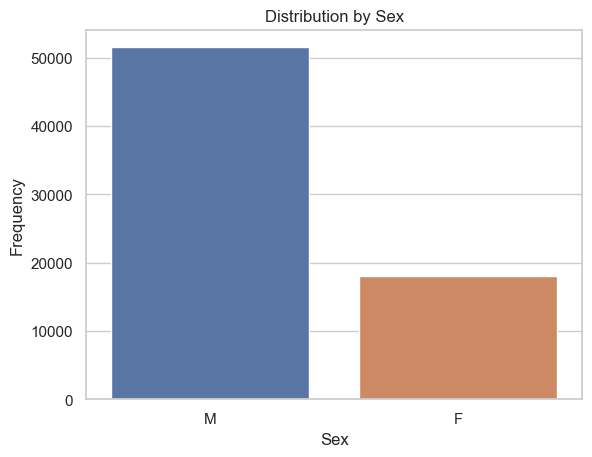

In [222]:
sns.countplot(data=data, x="Sex")
plt.title("Distribution by Sex")
plt.xlabel("Sex")
plt.ylabel("Frequency")
plt.show()

Male athletes appear more frequently in the dataset, reflecting historical patterns where male participation dominated earlier Olympic Games.

### Age Distribution of Athletes

Understanding athlete age helps identify the typical age range for Olympic participation.

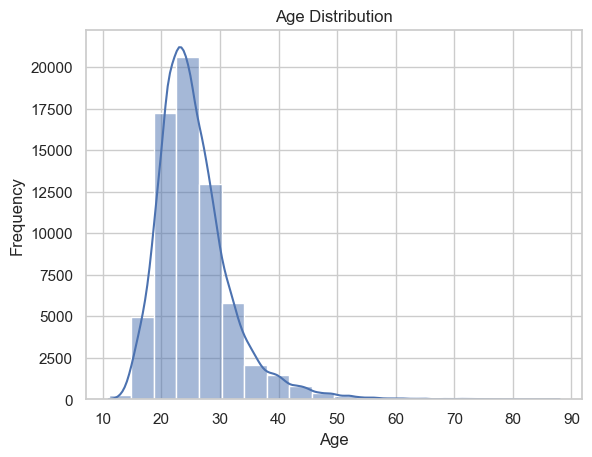

In [223]:
sns.histplot(data=data, x="Age", bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

Most athletes fall between ages 20 and 30, suggesting that Olympic athletes typically compete during their peak physical performance years.

### Physical Attributes

Height and weight distributions provide insights into the physical characteristics of Olympic athletes.

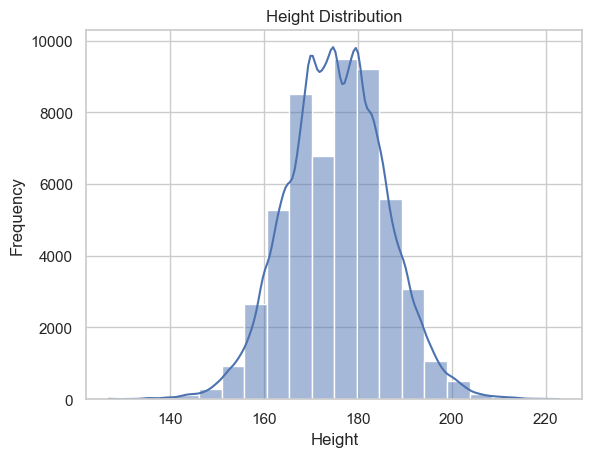

In [224]:
sns.histplot(data=data, x="Height", bins=20, kde=True)
plt.title("Height Distribution")
plt.xlabel("Height")
plt.ylabel("Frequency")
plt.show()

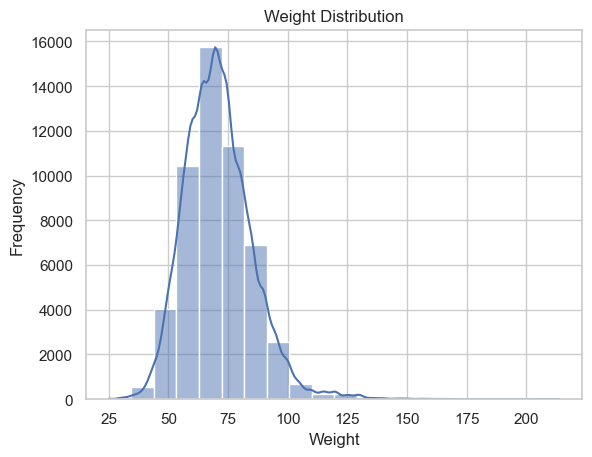

In [225]:
sns.histplot(data=data, x="Weight", bins=20, kde=True)
plt.title("Weight Distribution")
plt.xlabel("Weight")
plt.ylabel("Frequency")
plt.show()

Athlete height and weight vary considerably across the dataset, reflecting the different physical requirements of Olympic sports.

## 6. Medal Analysis

We analyze how medals are distributed across athletes in the dataset.

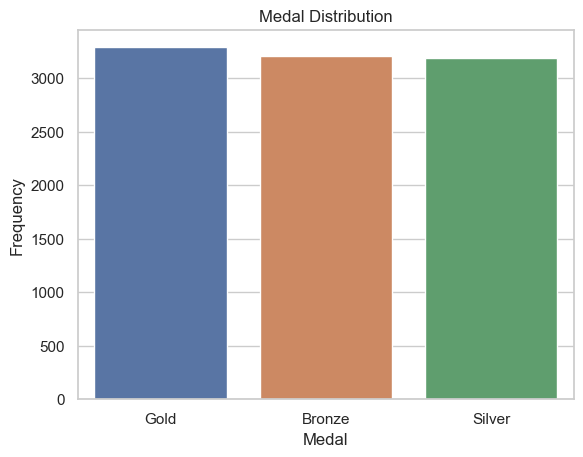

In [239]:
sns.countplot(data=data, x="Medal")
plt.title("Medal Distribution")
plt.xlabel("Medal")
plt.ylabel("Frequency")
plt.show()

Only a small proportion of Olympic participants win medals, reflecting the highly competitive nature of Olympic events.

### Medal Distribution by Year

This visualization examines how the number of medals awarded changes across Olympic years.

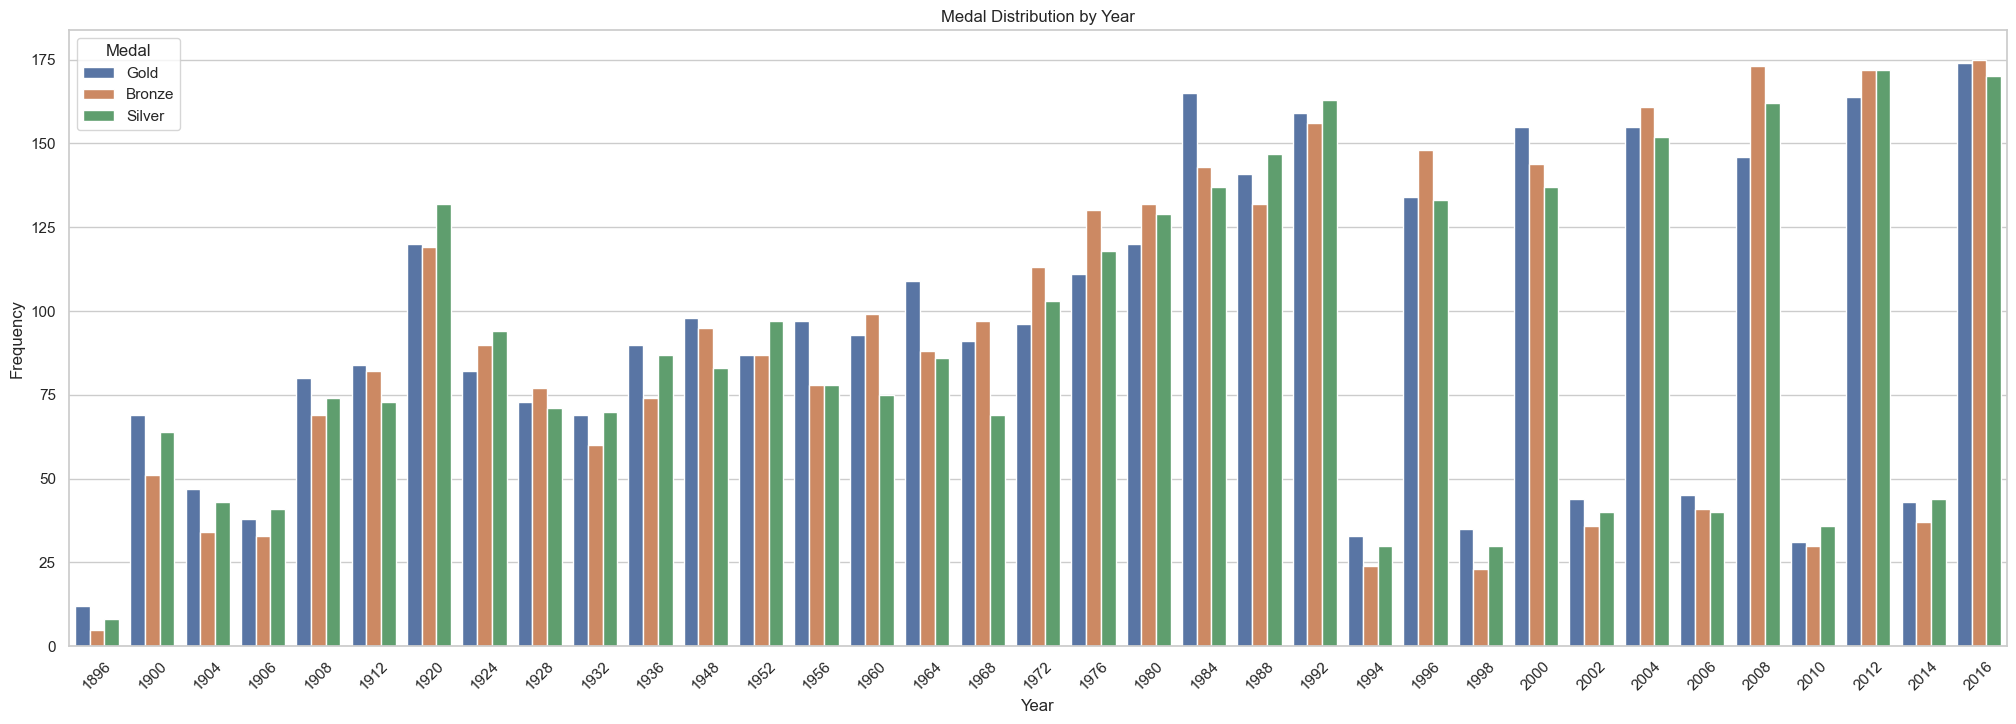

In [227]:
plt.figure(figsize=(25, 8))
sns.countplot(data=data, x="Year", hue="Medal")
plt.title("Medal Distribution by Year")
plt.xlabel("Year")  
plt.ylabel("Frequency")
plt.legend(title="Medal")
plt.xticks(rotation=45)
plt.show()

## 7. Aggregated Analysis

We use groupby operations to identify patterns across years, sports, and countries.

### 7.1 Trends Over Time

This section explores how athlete characteristics and participation have evolved across different Olympic years.

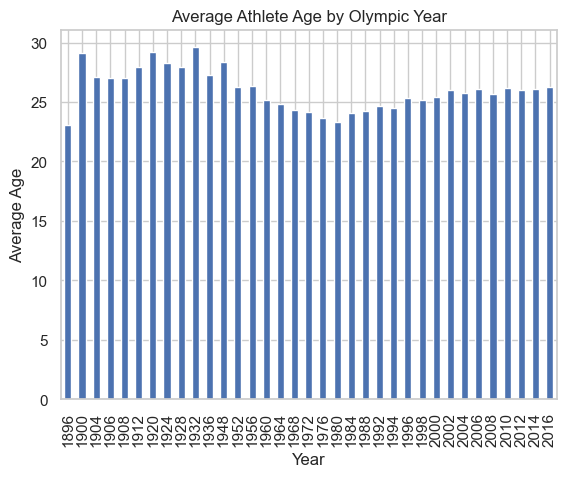

In [228]:
year_avg_age = data.groupby("Year")["Age"].mean()
year_avg_age.plot(kind="bar")
plt.title("Average Athlete Age by Olympic Year")
plt.ylabel("Average Age")
plt.xlabel("Year")
plt.show()

The average age of Olympic athletes has remained relatively stable across Olympic years, typically in the mid-20s. This suggests that peak athletic performance occurs within this age range.

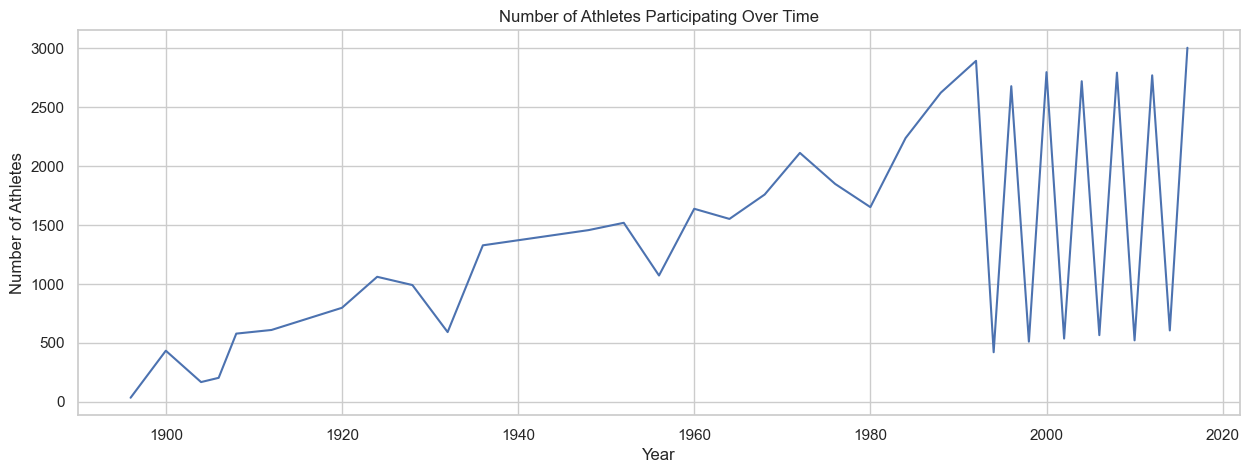

In [229]:
plt.figure(figsize=(15, 5))
year_participation_count = data.groupby("Year")["ID"].nunique()
year_participation_count.plot()
plt.title("Number of Athletes Participating Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Athletes")
plt.show()

The number of participating athletes has increased significantly over time, reflecting the global expansion of the Olympic Games and increased participation from more countries.

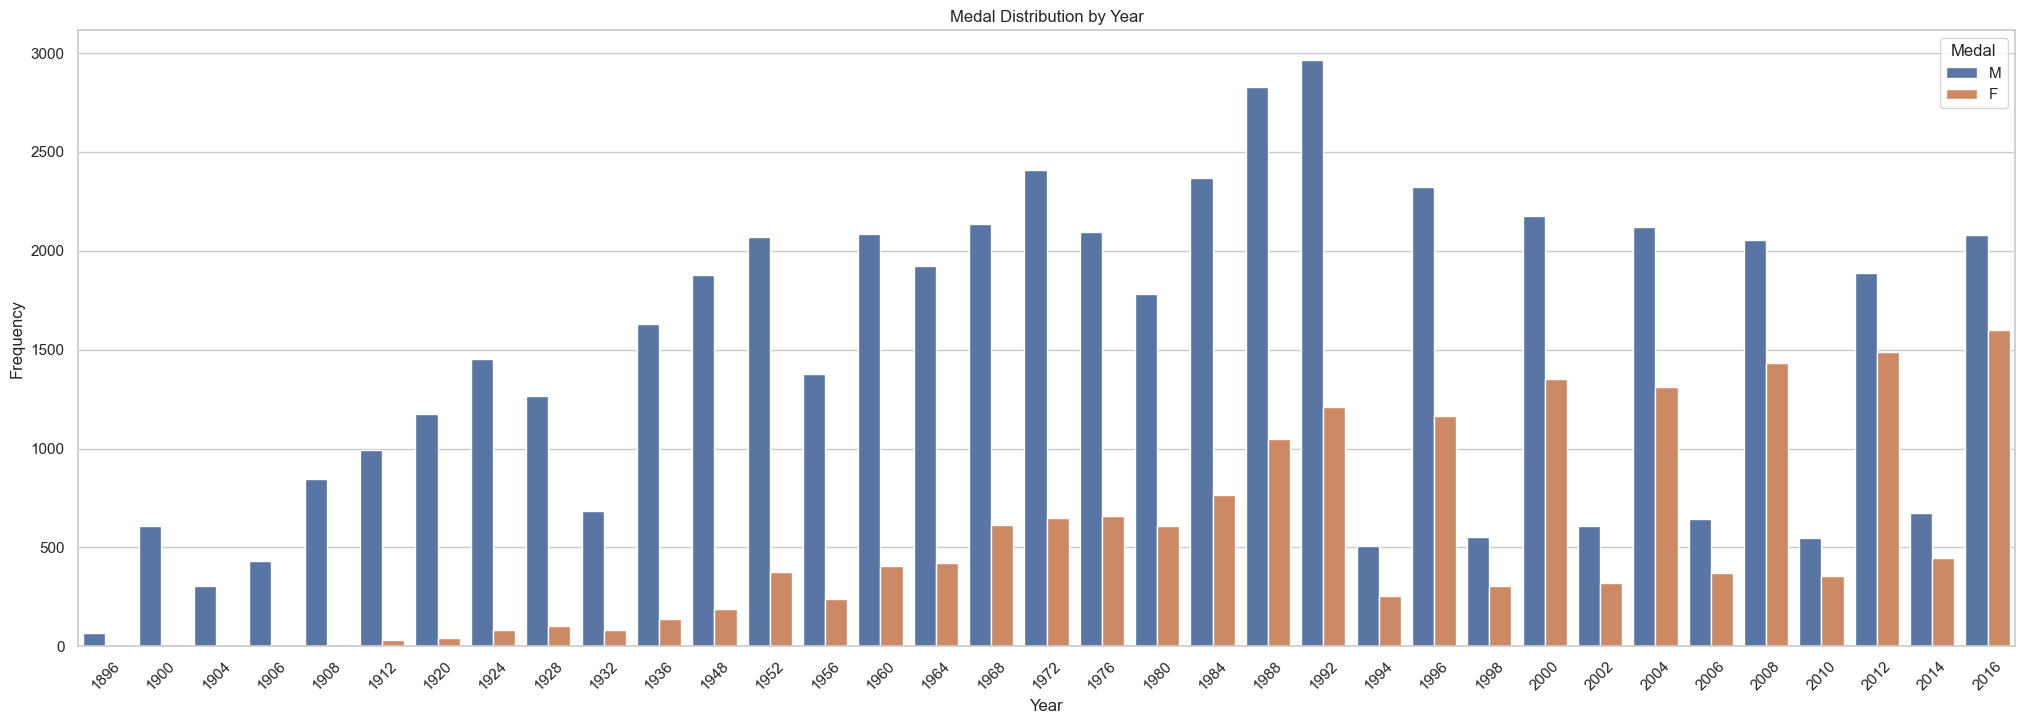

In [230]:
plt.figure(figsize=(25, 8))
sns.countplot(data=data, x="Year", hue="Sex")
plt.title("Medal Distribution by Year")
plt.xlabel("Year")  
plt.ylabel("Frequency")
plt.legend(title="Medal")
plt.xticks(rotation=45)
plt.show()

Female participation has increased steadily over time, reflecting the growing inclusion of women in Olympic sports.

### 7.2 Sport-Based Analysis

Different Olympic sports require different physical attributes and body profiles. This section explores how athlete characteristics vary across sports by examining the median height of athletes in each sport.

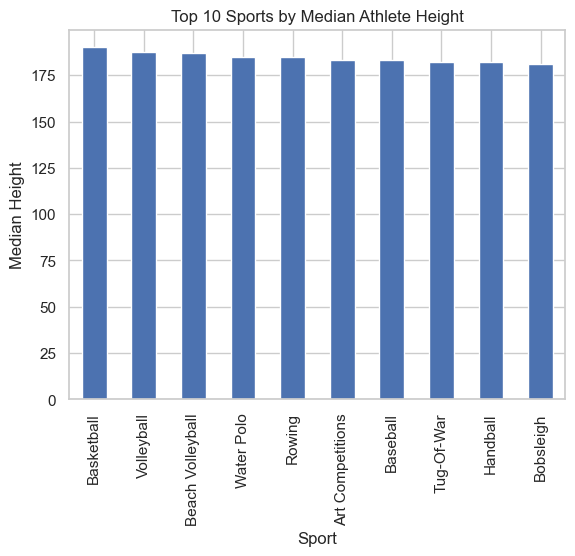

In [231]:
sport_median_height = data.groupby("Sport")["Height"].median().sort_values(ascending=False).head(10)
sport_median_height.plot(kind="bar")
plt.title("Top 10 Sports by Median Athlete Height")
plt.ylabel("Median Height")
plt.show()

Sports appearing at the top of the chart tend to involve taller athletes, suggesting that height may provide a physical advantage in certain Olympic events.

### 7.3 Country-Level Analysis

This section explores participation and medal performance across different countries.

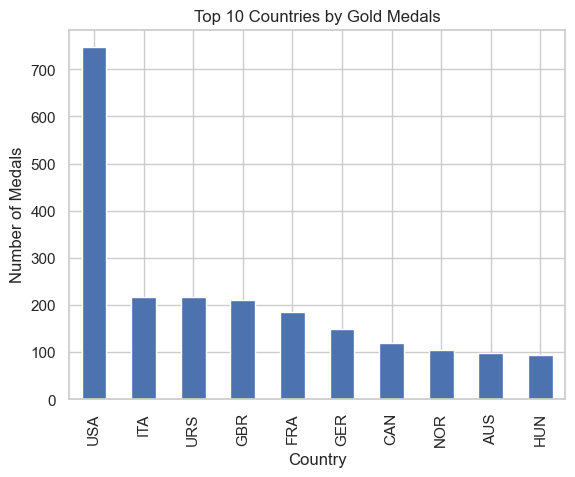

In [232]:
country_gold_medals = data[data["Medal"] == "Gold"].groupby("NOC")["ID"].count()

top_gold = country_gold_medals.sort_values(ascending=False).head(10)

top_gold.plot(kind="bar")
plt.title("Top 10 Countries by Gold Medals")
plt.xlabel("Country")
plt.ylabel("Number of Medals")
plt.show()

A relatively small group of countries consistently dominates Olympic gold medal counts, reflecting strong investment in sports training programs and athlete development.

## 8. Seasonal Analysis

We compare athlete age distributions between Summer and Winter Olympic Games.

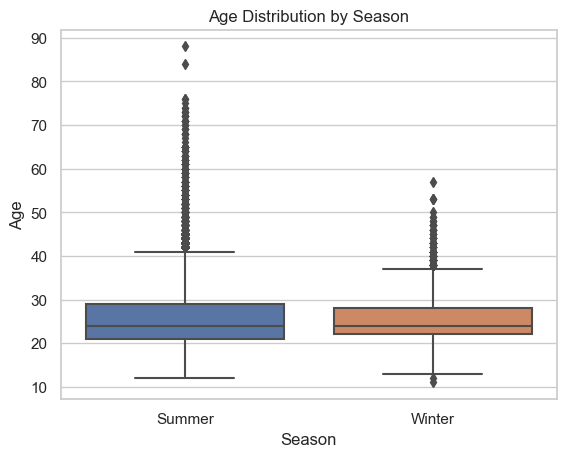

In [233]:
sns.boxplot(data=data, x="Season", y="Age")
plt.title("Age Distribution by Season")
plt.xlabel("Season")    
plt.ylabel("Age")
plt.show()

Winter and Summer Olympic athletes have similar age distributions, though Winter athletes tend to show slightly wider variation. This may reflect the technical nature of many winter sports, where experience plays a larger role.

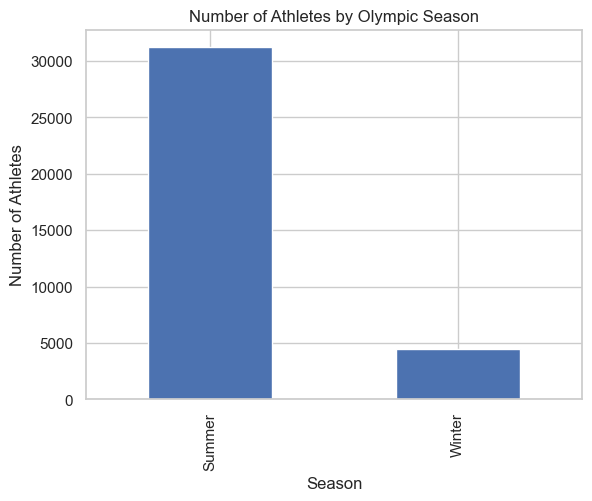

In [234]:
season_counts = data.groupby("Season")["ID"].nunique()
season_counts.plot(kind="bar")
plt.title("Number of Athletes by Olympic Season")
plt.xlabel("Season")
plt.ylabel("Number of Athletes")
plt.show()

The Summer Olympics include significantly more athletes than the Winter Olympics, reflecting the larger number of sports and participating nations.

## 9. Interesting Athlete Records

We identify extreme athlete characteristics such as the tallest, heaviest, and lightest athletes in the dataset.

In [235]:
tallest_athlete = data[data["Height"] == data["Height"].max()]
print("Tallest Athlete:\n", tallest_athlete[["ID", "Name", "Height", "Sport"]])


Tallest Athlete:
           ID                  Name  Height       Sport
32376  16639  Tommy Loren Burleson   223.0  Basketball


In [236]:
heaviest_athlete = data[data["Weight"] == data["Weight"].max()]
print("Heaviest Athlete:\n", heaviest_athlete[["ID", "Name", "Weight", "Sport"]])

Heaviest Athlete:
           ID               Name  Weight Sport
23155  12177  Ricardo Blas, Jr.   214.0  Judo
23156  12177  Ricardo Blas, Jr.   214.0  Judo


In [237]:
lightest_athlete = data[data["Weight"] == data["Weight"].min()]
print("Lightest Athlete:\n", lightest_athlete[["ID", "Name", "Weight", "Sport"]])

Lightest Athlete:
           ID            Name  Weight       Sport
40849  21049  Choi Myong-Hui    25.0  Gymnastics
40850  21049  Choi Myong-Hui    25.0  Gymnastics
40851  21049  Choi Myong-Hui    25.0  Gymnastics
40852  21049  Choi Myong-Hui    25.0  Gymnastics
40853  21049  Choi Myong-Hui    25.0  Gymnastics
40854  21049  Choi Myong-Hui    25.0  Gymnastics


## 10. Relationship Between Height and Weight

We examine whether athlete height and weight show a correlation.

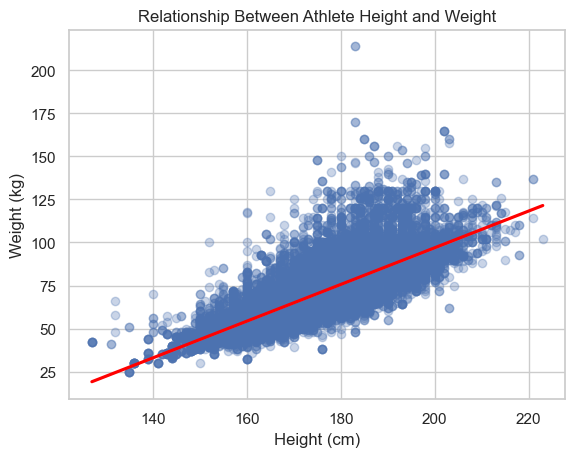

Correlation between Height and Weight: 0.78


In [238]:
sns.regplot(
    data=data,
    x="Height",
    y="Weight",
    scatter_kws={"alpha":0.3},  
    line_kws={"color":"red"}    
)

plt.title("Relationship Between Athlete Height and Weight")
plt.xlabel("Height (cm)")
plt.ylabel("Weight (kg)")
plt.show()

height_weight_corr = data["Height"].corr(data["Weight"])

print(f"Correlation between Height and Weight: {height_weight_corr:.2f}")

The visualization shows a positive relationship between athlete height and weight. Taller athletes generally tend to weigh more, which is consistent with natural body proportions and the physical requirements of many sports. 

The correlation coefficient quantifies this relationship, confirming a moderate positive association between these two variables.

# Key Insights

1. Most Olympic athletes fall within the 20–30 age range, indicating that elite athletic performance is commonly achieved during this period.

2. Male athletes historically dominate Olympic participation, though female participation has increased.

3. Athlete participation has steadily increased across Olympic years, suggesting global growth in Olympic involvement.

4. Medal distribution is concentrated among a limited number of athletes and countries, highlighting the competitive nature of Olympic events.

5. Certain sports such as basketball and volleyball tend to feature taller athletes due to physical advantages.

6. Height and weight show a positive correlation, indicating that taller athletes generally weigh more.

# Conclusion

This exploratory data analysis examined Olympic athlete data to identify patterns in demographics, participation trends, medal outcomes, and physical attributes. The analysis highlights the typical age range of Olympic athletes, the growth of global participation, patterns in medal distribution, and the role of physical characteristics in different sports.